In [1]:
# @title 1. 环境设置与依赖项安装
# ------------------------------------------------------------------------------
# 清理可能已存在的旧的仓库目录，确保全新克隆
# ------------------------------------------------------------------------------
!rm -rf /content/Time-Series-Library
!rm -rf /content/NAB
print("Cleaned up any existing Time-Series-Library and NAB directories.")

# ------------------------------------------------------------------------------
# 克隆 TimesNet 代码库 (来自THUML) 和 NAB 数据集代码库
# ------------------------------------------------------------------------------
!git clone https://github.com/thuml/Time-Series-Library.git /content/Time-Series-Library
print("Time-Series-Library (containing TimesNet) repository cloned.")
!git clone https://github.com/numenta/NAB.git /content/NAB
print("NAB repository cloned.")

# ------------------------------------------------------------------------------
# 将代码库的路径添加到 sys.path
# ------------------------------------------------------------------------------
import sys
TIMESNET_PATH = '/content/Time-Series-Library'
if TIMESNET_PATH not in sys.path:
    sys.path.insert(0, TIMESNET_PATH)
print(f"Path '{TIMESNET_PATH}' added to sys.path.")

# ------------------------------------------------------------------------------
# 安装必要的依赖
# ------------------------------------------------------------------------------
!pip install einops pandas numpy matplotlib scikit-learn torch torchvision torchaudio sympy -q
print("Installed/checked necessary packages.")

# ------------------------------------------------------------------------------
# 导入标准库
# ------------------------------------------------------------------------------
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler # 必要的缩放处理
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import json
import os

# ------------------------------------------------------------------------------
# 从克隆的库中导入 TimesNet 模型类
# ------------------------------------------------------------------------------
try:
    # TimesNet 模型在 models/TimesNet.py 中定义为 Model 类
    from models.TimesNet import Model as TimesNetModel
    print("Successfully imported TimesNet model class as TimesNetModel.")
except ImportError as e:
    print(f"ERROR: Could not import TimesNet model: {e}")
    print("Please check the file structure in '/content/Time-Series-Library/models/' and ensure cloning was successful.")
    if os.path.exists(os.path.join(TIMESNET_PATH, 'models')):
         print(f"Listing files in '{TIMESNET_PATH}/models/': {os.listdir(os.path.join(TIMESNET_PATH, 'models'))}")
    raise
except Exception as e_other:
    print(f"An unexpected error occurred during TimesNet import: {e_other}")
    raise

# ------------------------------------------------------------------------------
# 设置设备 (GPU 或 CPU)
# ------------------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------------------------
# 打印环境信息
# ------------------------------------------------------------------------------
print(f"\n--- Environment Setup ---")
print(f"Using device: {device}")
print(f"PyTorch Version: {torch.__version__}")
if torch.cuda.is_available():
    print(f"CUDA available. GPU: {torch.cuda.get_device_name(0)}")
    if hasattr(torch.version, 'cuda'):
        print(f"PyTorch built with CUDA version: {torch.version.cuda}")
else:
    print("CUDA not available. Running on CPU.")
print(f"--- Setup Complete ---")

Cleaned up any existing Time-Series-Library and NAB directories.
Cloning into '/content/Time-Series-Library'...
remote: Enumerating objects: 2023, done.
remote: Counting objects: 100% (1211/1211), done.
remote: Compressing objects: 100% (145/145), done.
remote: Total 2023 (delta 1083), reused 1066 (delta 1066), pack-reused 812 (from 1)
Receiving objects: 100% (2023/2023), 78.28 MiB | 12.70 MiB/s, done.
Resolving deltas: 100% (1406/1406), done.
Time-Series-Library (containing TimesNet) repository cloned.
Cloning into '/content/NAB'...
remote: Enumerating objects: 7119, done.
remote: Counting objects: 100% (713/713), done.
remote: Compressing objects: 100% (204/204), done.
remote: Total 7119 (delta 561), reused 519 (delta 504), pack-reused 6406 (from 1)
Receiving objects: 100% (7119/7119), 86.76 MiB | 13.67 MiB/s, done.
Resolving deltas: 100% (4984/4984), done.
Updating files: 100% (1186/1186), done.
NAB repository cloned.
Path '/content/Time-Series-Library' added to sys.path.
   ━━━━━━━

--- Data Loading and Label Processing (NAB Dataset) ---
Attempting to load data for: artificialWithAnomaly/art_load_balancer_spikes.csv
Successfully loaded data from: /content/NAB/data/artificialWithAnomaly/art_load_balancer_spikes.csv
Initial data shape: (4032, 2)
Data columns: ['timestamp', 'value']
Timestamp column processed and set as DatetimeIndex.
Found 1 raw anomaly window(s) for 'artificialWithAnomaly/art_load_balancer_spikes.csv'.
Label processing complete. Processed 1 anomaly window(s) that mapped to data points.
Total data points initially marked as anomalous in data_df: 403

Prepared 'raw_time_series_values' (shape: (4032, 1)).
Prepared 'pointwise_true_labels' (total anomalies: 403).


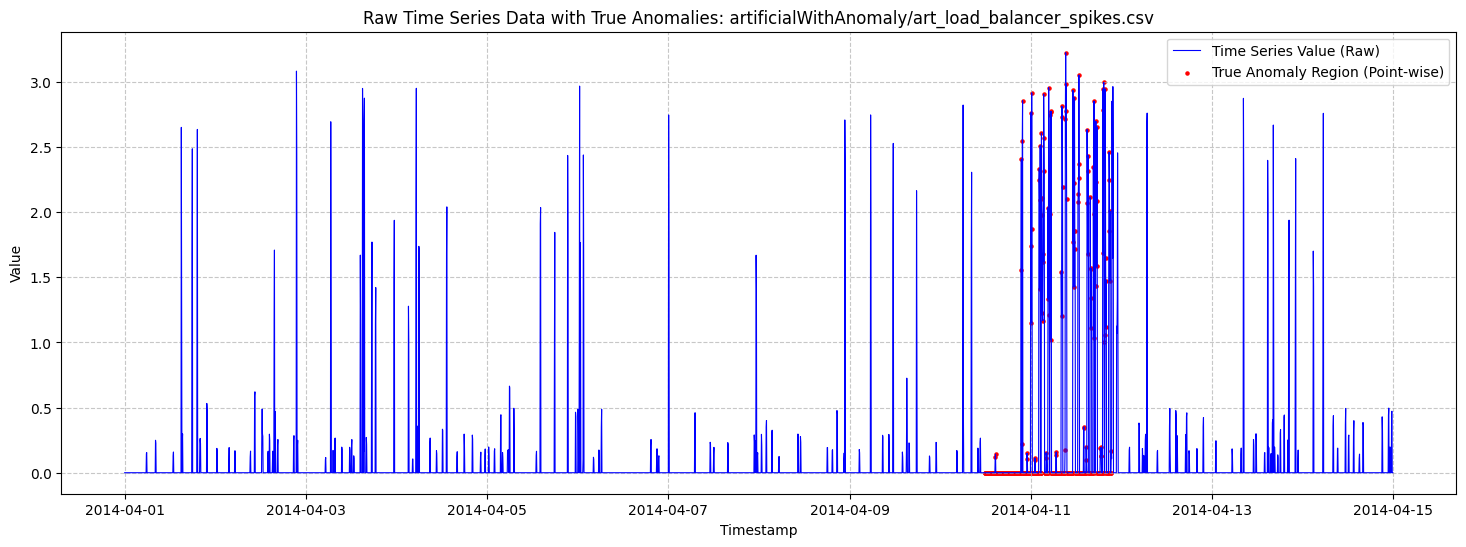

--- Data Loading and Label Processing Complete ---


In [9]:
# @title 2. NAB 数据加载与标签处理
# ------------------------------------------------------------------------------
# 用户指定参数：选择 NAB 数据集中的哪个文件进行处理
# 例如: 'realKnownCause/nyc_taxi.csv' 或 'realAWSCloudwatch/ec2_cpu_utilization_fe7f93.csv'
# 你可以从 /content/NAB/data/ 目录中查看可用的文件
# ------------------------------------------------------------------------------
#NAB_DATA_FILE_RELATIVE_PATH = 'realKnownCause/nyc_taxi.csv' # <--- 修改这里选择不同的NAB数据文件
# NAB_DATA_FILE_RELATIVE_PATH = 'realAWSCloudwatch/ec2_cpu_utilization_ac20cd.csv'
# NAB_DATA_FILE_RELATIVE_PATH = 'realTraffic/occupancy_6005.csv'
# NAB_DATA_FILE_RELATIVE_PATH = 'artificialNoAnomaly/art_daily_flatmiddle.csv'
NAB_DATA_FILE_RELATIVE_PATH = 'artificialWithAnomaly/art_load_balancer_spikes.csv'


DATA_FILE_COLAB_PATH = f'/content/NAB/data/{NAB_DATA_FILE_RELATIVE_PATH}'
LABEL_FILE_COLAB_PATH = '/content/NAB/labels/combined_windows.json' # NAB 通用的标签文件
JSON_KEY_FOR_LABELS = NAB_DATA_FILE_RELATIVE_PATH # JSON 文件中的键通常是相对路径

print(f"--- Data Loading and Label Processing (NAB Dataset) ---")
print(f"Attempting to load data for: {NAB_DATA_FILE_RELATIVE_PATH}")

data_df = None
raw_time_series_values = None
pointwise_true_labels = None

if not os.path.exists(DATA_FILE_COLAB_PATH):
    print(f"ERROR: Data file not found: {DATA_FILE_COLAB_PATH}")
    print(f"Please ensure the relative path '{NAB_DATA_FILE_RELATIVE_PATH}' is correct and the file exists in '/content/NAB/data/'.")
    print(f"Available top-level directories in /content/NAB/data/: {os.listdir('/content/NAB/data/')}")
else:
    try:
        data_df = pd.read_csv(DATA_FILE_COLAB_PATH)
        print(f"Successfully loaded data from: {DATA_FILE_COLAB_PATH}")
        print(f"Initial data shape: {data_df.shape}")
        print(f"Data columns: {data_df.columns.tolist()}")
        # print(data_df.head())

        # 时间戳处理 (与temp.py一致)
        if 'timestamp' not in data_df.columns:
            raise ValueError("Column 'timestamp' not found in the CSV file.")
        data_df['timestamp'] = pd.to_datetime(data_df['timestamp'])
        data_df = data_df.set_index('timestamp')
        print("Timestamp column processed and set as DatetimeIndex.")

        if 'value' not in data_df.columns:
            raise ValueError("Column 'value' not found in the CSV file. Please ensure your data has a 'value' column for the time series readings.")

    except Exception as e:
        print(f"Error during data loading or initial timestamp processing: {e}")
        data_df = None # Ensure data_df is None if loading fails

if data_df is not None and 'value' in data_df.columns:
    # 初始化逐点标签列 (与temp.py一致)
    data_df['is_anomaly_pointwise'] = 0
    parsed_anomaly_windows_count = 0

    if not os.path.exists(LABEL_FILE_COLAB_PATH):
        print(f"WARNING: Label file not found: {LABEL_FILE_COLAB_PATH}. Proceeding without anomaly labels.")
    else:
        try:
            with open(LABEL_FILE_COLAB_PATH, 'r') as f:
                all_labels_json = json.load(f)

            # 获取当前数据文件对应的异常窗口 (与temp.py一致)
            raw_anomaly_windows_list = all_labels_json.get(JSON_KEY_FOR_LABELS, [])

            if not raw_anomaly_windows_list:
                print(f"No anomaly windows found in '{LABEL_FILE_COLAB_PATH}' for key '{JSON_KEY_FOR_LABELS}'. This might be expected for anomaly-free datasets.")
            else:
                print(f"Found {len(raw_anomaly_windows_list)} raw anomaly window(s) for '{JSON_KEY_FOR_LABELS}'.")
                for window_event in raw_anomaly_windows_list:
                    if isinstance(window_event, list) and len(window_event) == 2:
                        try:
                            start_ts_str, end_ts_str = window_event
                            # NAB时间戳格式可能多样，尝试多种解析
                            try:
                                start_ts = pd.to_datetime(start_ts_str)
                                end_ts = pd.to_datetime(end_ts_str)
                            except ValueError:
                                # 有些 NAB 时间戳可能需要特定格式，例如 '%Y-%m-%d %H:%M:%S.%f'
                                # 对于大多数NAB CSV，直接 pd.to_datetime 应该能工作
                                print(f"  Warning: Could not parse window event {window_event} directly, attempting with common NAB formats.")
                                start_ts = pd.to_datetime(start_ts_str, errors='coerce')
                                end_ts = pd.to_datetime(end_ts_str, errors='coerce')
                                if pd.isna(start_ts) or pd.isna(end_ts):
                                     raise ValueError(f"Failed to parse timestamps: {start_ts_str}, {end_ts_str}")

                            anomalous_points_mask = (data_df.index >= start_ts) & (data_df.index <= end_ts)
                            data_df.loc[anomalous_points_mask, 'is_anomaly_pointwise'] = 1
                            if anomalous_points_mask.sum() > 0:
                                parsed_anomaly_windows_count += 1
                        except Exception as e_win:
                            print(f"  Warning: Could not process window event {window_event} for labeling: {e_win}")
                print(f"Label processing complete. Processed {parsed_anomaly_windows_count} anomaly window(s) that mapped to data points.")
                print(f"Total data points initially marked as anomalous in data_df: {data_df['is_anomaly_pointwise'].sum()}")
        except Exception as e_label:
            print(f"An error occurred during label processing: {e_label}")
            print("Proceeding with potentially no or incomplete labels.")

    # 准备原始时间序列值和逐点真实标签 (与temp.py一致)
    raw_time_series_values = data_df['value'].values.reshape(-1, 1)
    pointwise_true_labels = data_df['is_anomaly_pointwise'].values

    print(f"\nPrepared 'raw_time_series_values' (shape: {raw_time_series_values.shape}).")
    print(f"Prepared 'pointwise_true_labels' (total anomalies: {pointwise_true_labels.sum()}).")

    # 绘制原始数据和真实异常 (与temp.py一致)
    plt.figure(figsize=(18, 6))
    plt.plot(data_df.index, data_df['value'], label='Time Series Value (Raw)', color='blue', linewidth=0.8)
    anomalous_data_plot = data_df[data_df['is_anomaly_pointwise'] == 1]
    if not anomalous_data_plot.empty:
        plt.scatter(anomalous_data_plot.index, anomalous_data_plot['value'], color='red', label='True Anomaly Region (Point-wise)', marker='.', s=20)
    plt.title(f"Raw Time Series Data with True Anomalies: {JSON_KEY_FOR_LABELS}")
    plt.xlabel("Timestamp")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
elif data_df is not None and 'value' not in data_df.columns:
    print("ERROR: 'value' column is missing from the loaded DataFrame. Cannot proceed with TimesNet.")
    raw_time_series_values = None
    pointwise_true_labels = None
else:
    print("data_df was not loaded successfully. Cannot proceed with data preparation.")
    # Ensure variables are None if data loading failed earlier
    raw_time_series_values = None
    pointwise_true_labels = None

print(f"--- Data Loading and Label Processing Complete ---")


In [10]:
# @title 3. 数据准备 (缩放、窗口化、窗口级别标签)
# ------------------------------------------------------------------------------
# 注意：用户要求“不要做数据的预处理”。然而，对于神经网络模型如TimesNet，
# 输入数据的缩放 (例如归一化到0-1范围) 和窗口化是标准的、必要的数据准备步骤，
# 以确保模型能够有效学习。这里执行的是这些基础准备，而非复杂的特征工程。
# ------------------------------------------------------------------------------
print(f"\n--- Data Preparation for TimesNet (Scaling, Windowing, Window-Level Labels) ---")
X_tensor = None
dataloader = None
window_level_true_labels = None
WINDOW_SIZE = None # Will be set if data is valid
time_series_scaled = None # Will hold scaled data
X_windowed_data_np = None # Will hold windowed numpy data

if raw_time_series_values is not None and pointwise_true_labels is not None and len(raw_time_series_values) > 0:
    # 数据缩放 (与temp.py一致)
    scaler = MinMaxScaler(feature_range=(0, 1)) # TimesNet常在(0,1)或标准化数据上工作
    time_series_scaled = scaler.fit_transform(raw_time_series_values)
    print(f"Raw data scaled. Shape: {time_series_scaled.shape}")

    # TimesNet 的输入窗口长度 (seq_len) (与temp.py一致)
    # 对于5分钟间隔的NAB数据 (很多是这样), 96 点是 96*5 = 480分钟 = 8小时。
    # 一天的数据点大约是 24 * (60/5) = 288。可以根据具体数据集的特性调整。
    # 常见的选择是覆盖一到数个典型周期。
    WINDOW_SIZE = 96 # 保持与temp.py一致，可调整
    print(f"Using WINDOW_SIZE (seq_len for TimesNet): {WINDOW_SIZE}")

    if len(time_series_scaled) < WINDOW_SIZE:
        print(f"ERROR: Data length ({len(time_series_scaled)}) is less than WINDOW_SIZE ({WINDOW_SIZE}). Cannot create windows.")
        X_tensor = None
        dataloader = None
        window_level_true_labels = None
    else:
        # 创建窗口 (与temp.py一致)
        def create_windows_for_timesnet(input_data, window_length):
            windows = []
            for i in range(len(input_data) - window_length + 1):
                window = input_data[i : i + window_length]
                windows.append(window)
            return np.array(windows)

        X_windowed_data_np = create_windows_for_timesnet(time_series_scaled, WINDOW_SIZE)

        if X_windowed_data_np.shape[0] > 0:
            print(f"Created windows. Shape: {X_windowed_data_np.shape}") # (N_windows, WINDOW_SIZE, N_features)

            # 转换为 PyTorch 张量并移到设备 (与temp.py一致)
            X_tensor = torch.tensor(X_windowed_data_np, dtype=torch.float32).to(device)
            y_tensor_target = X_tensor.detach().clone() # 重构任务的目标是自身
            print(f"X_tensor shape: {X_tensor.shape}, y_tensor_target shape: {y_tensor_target.shape}")

            # 创建窗口级别的真实标签 (与temp.py一致)
            num_windows = X_windowed_data_np.shape[0]
            temp_window_labels = []
            for i in range(num_windows):
                # 检查窗口对应的原始点是否有任何异常
                original_points_in_window_labels = pointwise_true_labels[i : i + WINDOW_SIZE]
                is_window_anomalous = np.any(original_points_in_window_labels == 1)
                temp_window_labels.append(1 if is_window_anomalous else 0)
            window_level_true_labels = np.array(temp_window_labels)
            print(f"Created window-level true labels. Shape: {window_level_true_labels.shape}, Anomalous windows: {window_level_true_labels.sum()}")

            # 创建 DataLoader (与temp.py一致)
            BATCH_SIZE_MODEL = 32 # 可调
            dataset = TensorDataset(X_tensor, y_tensor_target)
            dataloader = DataLoader(dataset, batch_size=BATCH_SIZE_MODEL, shuffle=True) # 打乱用于训练
            print(f"DataLoader created with batch size {BATCH_SIZE_MODEL}.")
        else:
            print("No windows were created (possibly due to insufficient data length after initial checks). Cannot proceed.")
            X_tensor = None
            dataloader = None
            window_level_true_labels = None
else:
    print("Skipping data preparation as raw input data ('raw_time_series_values' or 'pointwise_true_labels') is not available or empty.")

print(f"--- Data Preparation for TimesNet Complete ---")



--- Data Preparation for TimesNet (Scaling, Windowing, Window-Level Labels) ---
Raw data scaled. Shape: (4032, 1)
Using WINDOW_SIZE (seq_len for TimesNet): 96
Created windows. Shape: (3937, 96, 1)
X_tensor shape: torch.Size([3937, 96, 1]), y_tensor_target shape: torch.Size([3937, 96, 1])
Created window-level true labels. Shape: (3937,), Anomalous windows: 498
DataLoader created with batch size 32.
--- Data Preparation for TimesNet Complete ---


In [11]:
# @title 4. TimesNet 模型定义
# ------------------------------------------------------------------------------
# TimesNet 模型需要一个配置对象或一系列参数。
# 我们创建一个简单的类来模拟配置对象，参考 TimesNet 仓库中的代码。
# ------------------------------------------------------------------------------
print(f"\n--- TimesNet Model Definition ---")

model = None # Initialize model variable

if WINDOW_SIZE is not None and X_tensor is not None: # Ensure WINDOW_SIZE and X_tensor are valid
    class TimesNetConfigs:
        def __init__(self, current_window_size, num_features=1):
            self.seq_len = current_window_size  # 输入序列长度
            self.pred_len = 0              # 对于重构任务，预测长度设为0 (模型重构输入)
            self.enc_in = num_features     # 输入特征维度 (单变量为1)
            self.c_out = num_features      # 输出特征维度 (对于重构，与enc_in相同)

            # TimesNet 特定参数 (这些是常用默认值,可以调整)
            self.d_model = 64              # 模型隐藏层维度
            self.d_ff = 64                 # 前馈网络隐藏层维度
            self.num_kernels = 6           # Inception 块中的卷积核数量 (TimesNet原文用6)
            self.e_layers = 2              # Encoder 层数 (例如 1, 2, 3)
            self.top_k = 5                 # 选择最重要的 k 个周期进行 2D 变换
            self.dropout = 0.1             # Dropout 比例
            self.task_name = 'anomaly_detection' # 告知模型任务类型,模型内部可能会据此调整行为

            # 时间特征嵌入相关 (对于无监督重构且不传入额外时间特征，'fixed'是简单选择)
            self.embed = 'fixed'           # 'timeF', 'fixed', 'custom'. 'fixed'使用固定的位置编码
            self.freq = 'h'                # 虚拟频率，当embed='fixed'时，此参数影响不大但模型结构需要。
                                           # 's':秒, 't':分钟, 'h':小时, 'd':天. 对于NAB数据，很多是5min/15min/30min间隔，'t'或'h'均可。
            self.output_attention = False  # 对于重构任务，通常不需要注意力权重输出
            self.label_len = 0             # 解码器中用于辅助预测的已知标签序列长度，重构任务中为0

    try:
        # 获取输入特征数量 (通常是1，除非是多变量时间序列)
        n_features = X_tensor.shape[2] if X_tensor is not None else 1
        model_configs = TimesNetConfigs(WINDOW_SIZE, num_features=n_features)
        model = TimesNetModel(model_configs).float().to(device) # 确保模型在正确的设备上
        print("TimesNet model instantiated.")
        # print(model) # 取消注释可以打印模型结构

        if list(model.parameters()):
            print(f"Model is on device: {next(model.parameters()).device}")
        else:
            print("Warning: Model has no parameters (this is unusual).")

    except Exception as e_model_init:
        print(f"ERROR instantiating TimesNet model: {e_model_init}")
        import traceback
        traceback.print_exc()
        model = None # Ensure model is None if instantiation fails
else:
    print("Cannot instantiate TimesNet model: WINDOW_SIZE not set or X_tensor not available (likely due to data loading/preparation issues).")

print(f"--- Model Definition Complete ---")



--- TimesNet Model Definition ---
TimesNet model instantiated.
Model is on device: cuda:0
--- Model Definition Complete ---



--- Model Training (TimesNet for Reconstruction) ---
Starting training TimesNet for 10 epochs with LR=0.001...
Epoch [1/10], Loss: 0.0021349
Epoch [2/10], Loss: 0.0004426
Epoch [3/10], Loss: 0.0005223
Epoch [4/10], Loss: 0.0001379
Epoch [5/10], Loss: 0.0001050
Epoch [6/10], Loss: 0.0000764
Epoch [7/10], Loss: 0.0001031
Epoch [8/10], Loss: 0.0002324
Epoch [9/10], Loss: 0.0000771
Epoch [10/10], Loss: 0.0000584
Training finished.


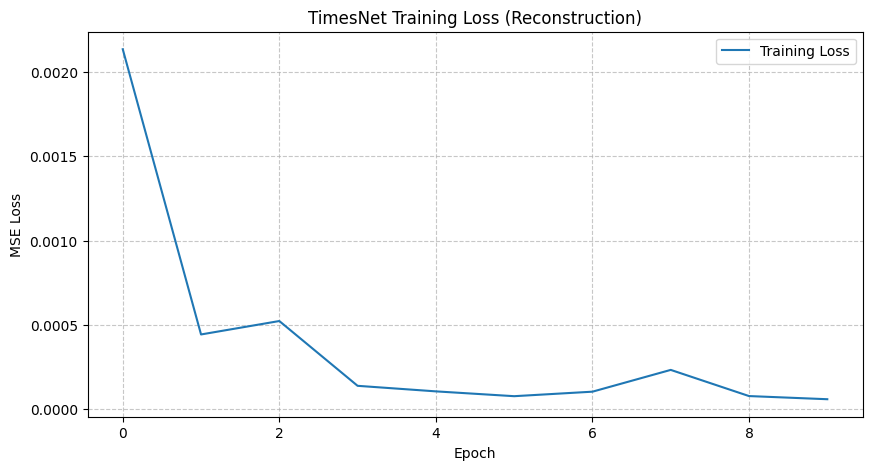

--- Model Training Complete ---


In [12]:
# @title 5. 模型训练 (TimesNet for Reconstruction)
# ------------------------------------------------------------------------------
# TimesNet 通过学习重构输入序列来进行异常检测。
# 异常点/窗口通常会导致比正常点/窗口更高的重构误差。
# ------------------------------------------------------------------------------
print(f"\n--- Model Training (TimesNet for Reconstruction) ---")
history = {'train_loss': []} # Initialize history

if model is not None and dataloader is not None :
    # TimesNet 的训练参数 (可调整)
    NUM_EPOCHS_TIMESNET = 10 # 先用少量轮次测试，实际可能需要更多，例如 10-50
    LEARNING_RATE_TIMESNET = 0.001 # 常见学习率

    criterion = nn.MSELoss() # 均方误差损失，用于重构
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE_TIMESNET)

    print(f"Starting training TimesNet for {NUM_EPOCHS_TIMESNET} epochs with LR={LEARNING_RATE_TIMESNET}...")

    for epoch in range(NUM_EPOCHS_TIMESNET):
        model.train() # 设置为训练模式
        epoch_loss = 0
        for batch_x, batch_y_true_reconstruction in dataloader: # batch_x 和 batch_y_true_reconstruction 是相同的
            # batch_x 和 batch_y_true_reconstruction 已经通过 DataLoader 放在了正确的 device 上
            optimizer.zero_grad()

            # TimesNet模型的forward调用:
            # forward(self, x_enc, x_mark_enc, x_dec, x_mark_dec, mask=None)
            # - x_enc: 输入序列 (batch_x)
            # - x_mark_enc: 输入序列的时间特征 (如果embed='timeF'或'custom'). 对于embed='fixed', 可以是None或全零.
            # - x_dec: 解码器输入。对于纯重构 (pred_len=0), TimesNet论文中通常将其设置为全零张量，
            #          形状与x_enc相同，作为解码器起始输入以重构整个序列。
            # - x_mark_dec: 解码器输入的时间特征. 对于embed='fixed', 可以是None或全零.

            # 为解码器创建一个与输入形状相同的全零张量作为输入
            dec_inp_dummy = torch.zeros_like(batch_x).float().to(device)

            # 当 embed='fixed' 时, x_mark_enc 和 x_mark_dec 可以设为 None
            outputs = model(batch_x, None, dec_inp_dummy, None)
            # outputs 的形状应该是 (BATCH_SIZE, model_configs.seq_len, model_configs.c_out)
            # 即与 batch_y_true_reconstruction 形状相同

            loss = criterion(outputs, batch_y_true_reconstruction)

            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_epoch_loss = epoch_loss / len(dataloader)
        history['train_loss'].append(avg_epoch_loss)
        if (epoch + 1) % 1 == 0 or epoch == NUM_EPOCHS_TIMESNET - 1 : # 每轮都打印或最后打印
            print(f"Epoch [{epoch+1}/{NUM_EPOCHS_TIMESNET}], Loss: {avg_epoch_loss:.7f}")
    print("Training finished.")

    # 绘制训练损失 (与temp.py一致)
    plt.figure(figsize=(10, 5))
    plt.plot(history['train_loss'], label='Training Loss')
    plt.title('TimesNet Training Loss (Reconstruction)')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
else:
    print("Skipping model training: model or dataloader is not available/valid.")
print(f"--- Model Training Complete ---")




--- Anomaly Score Calculation (TimesNet Reconstruction Error) ---
Calculated anomaly scores for 3937 sequences using TimesNet reconstruction.
Anomaly scores (from TimesNet reconstruction) mapped to time points.


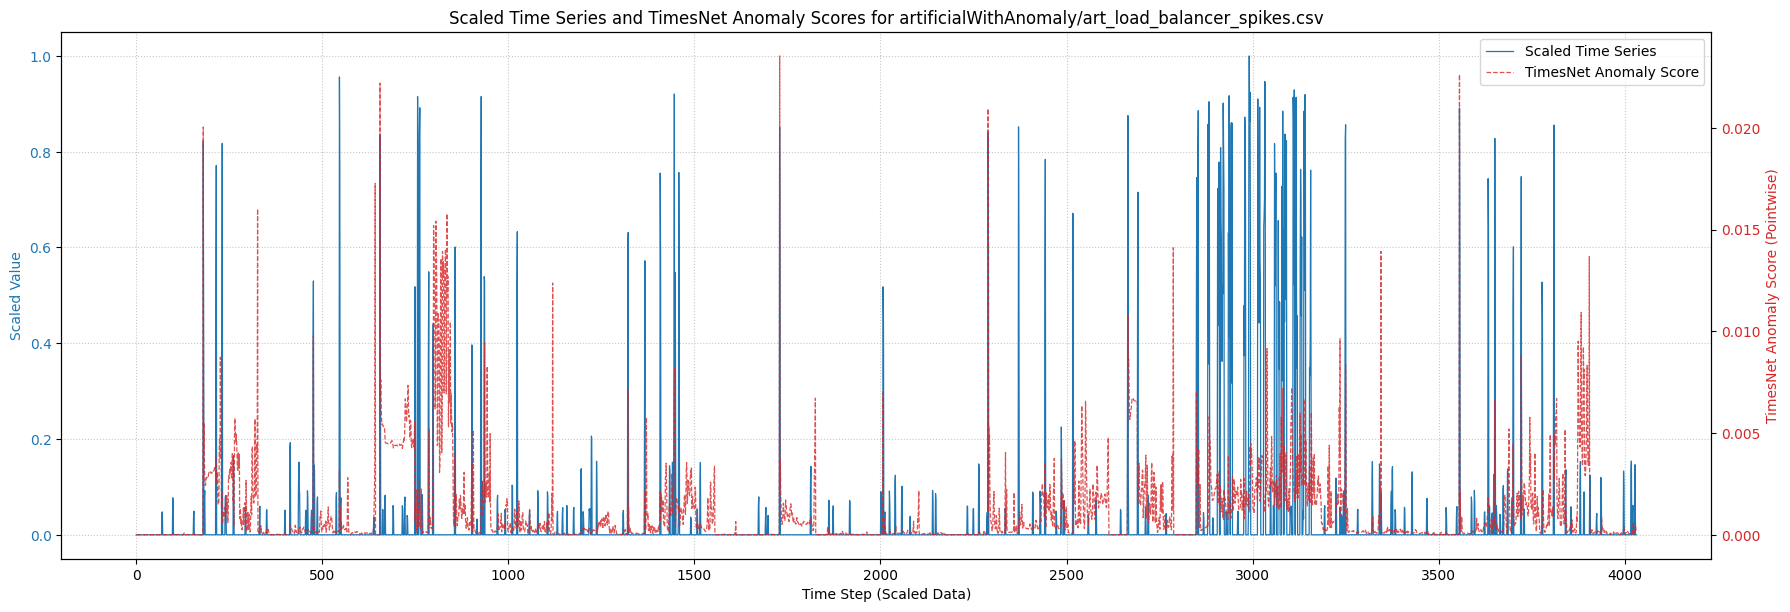

--- Anomaly Score Calculation (TimesNet) Complete ---


In [13]:
# @title 6. 异常分数计算 (TimesNet 重构误差)
# ------------------------------------------------------------------------------
# 使用训练好的模型对所有窗口进行重构，计算重构误差作为异常分数。
# 误差越大，越可能是异常。
# ------------------------------------------------------------------------------
print(f"\n--- Anomaly Score Calculation (TimesNet Reconstruction Error) ---")
anomaly_scores_per_sequence = None # 每个窗口/序列的异常分数
anomaly_scores_timesnet_pointwise = None # 映射回每个时间点的异常分数 (与 temp.py 的 anomaly_scores_timesnet 对应)

if (model is not None and
    X_tensor is not None and X_tensor.size(0) > 0 and
    WINDOW_SIZE is not None and time_series_scaled is not None and len(time_series_scaled) > 0):

    model.eval() # 设置为评估模式
    temp_anomaly_scores_per_sequence = [] # 临时存储每个序列的异常分数

    # 创建一个评估用的 DataLoader，不打乱顺序
    eval_dataset_tsn = TensorDataset(X_tensor, X_tensor) # 输入和目标相同
    eval_dataloader_tsn = DataLoader(eval_dataset_tsn, batch_size=BATCH_SIZE_MODEL, shuffle=False)

    # 用于计算逐点重构误差，然后聚合为序列分数
    reconstruction_criterion_none = nn.MSELoss(reduction='none').to(device)

    with torch.no_grad(): # 不计算梯度
        for batch_x, _ in eval_dataloader_tsn: # batch_x 已经在 device 上
            dec_inp_dummy_eval = torch.zeros_like(batch_x).float().to(device)
            reconstruction = model(batch_x, None, dec_inp_dummy_eval, None)

            # 计算每个时间点在每个特征上的平方误差
            # loss_pointwise shape: (BATCH_SIZE, WINDOW_SIZE, N_FEATURES)
            loss_pointwise = reconstruction_criterion_none(reconstruction, batch_x)

            # 对特征维度求平均 (如果是单变量，这一步不变)
            # loss_per_timestep shape: (BATCH_SIZE, WINDOW_SIZE)
            loss_per_timestep = loss_pointwise.mean(dim=-1)

            # temp.py 中采用的是窗口内所有时间点重构误差的最大值作为该窗口的异常分数
            # current_batch_anomaly_scores shape: (BATCH_SIZE,)
            current_batch_anomaly_scores = loss_per_timestep.max(dim=-1)[0] # 取最大值
            # 或者也可以用平均值: current_batch_anomaly_scores = loss_per_timestep.mean(dim=-1)

            temp_anomaly_scores_per_sequence.extend(current_batch_anomaly_scores.cpu().numpy())

    anomaly_scores_per_sequence = np.array(temp_anomaly_scores_per_sequence)
    print(f"Calculated anomaly scores for {len(anomaly_scores_per_sequence)} sequences using TimesNet reconstruction.")
    # print(f"Sample scores: {anomaly_scores_per_sequence[:5]}")

    # 将序列的异常分数映射回原始时间序列的每个点 (与 time_series_scaled 对齐)
    # (与 temp.py 的 anomaly_scores_timesnet 逻辑类似)
    # 每个窗口的异常分数被赋给该窗口的最后一个点。前面的点用第一个有效窗口的分数填充。
    anomaly_scores_timesnet_pointwise = np.full(len(time_series_scaled), np.nan)
    num_sequences_from_data = len(time_series_scaled) - WINDOW_SIZE + 1

    if len(anomaly_scores_per_sequence) == num_sequences_from_data:
        for i in range(len(anomaly_scores_per_sequence)):
            # 将窗口的异常分数赋给窗口的最后一个点
            anomaly_scores_timesnet_pointwise[i + WINDOW_SIZE - 1] = anomaly_scores_per_sequence[i]

        # 填充开头的 NaN 值 (用第一个有效窗口的分数填充)
        first_valid_idx_pointwise = np.where(~np.isnan(anomaly_scores_timesnet_pointwise))[0]
        if len(first_valid_idx_pointwise) > 0:
            anomaly_scores_timesnet_pointwise[:first_valid_idx_pointwise[0]] = anomaly_scores_timesnet_pointwise[first_valid_idx_pointwise[0]]
        else: # 如果全是NaN (例如数据太短没有有效窗口)
            anomaly_scores_timesnet_pointwise[:] = 0
        print("Anomaly scores (from TimesNet reconstruction) mapped to time points.")
    elif len(anomaly_scores_per_sequence) > 0:
        print(f"Warning: Length mismatch for TimesNet anomaly scores for pointwise mapping. Expected {num_sequences_from_data} scores from data, got {len(anomaly_scores_per_sequence)} scores from model output. This can happen if data was too short for some batches. Partial fill will be attempted.")
        fill_len = min(len(anomaly_scores_per_sequence), num_sequences_from_data)
        for i in range(fill_len):
             anomaly_scores_timesnet_pointwise[i + WINDOW_SIZE - 1] = anomaly_scores_per_sequence[i]
        if fill_len > 0:
            first_valid_idx_fill = np.where(~np.isnan(anomaly_scores_timesnet_pointwise))[0]
            if len(first_valid_idx_fill) > 0:
                anomaly_scores_timesnet_pointwise[:first_valid_idx_fill[0]] = anomaly_scores_timesnet_pointwise[first_valid_idx_fill[0]]
            else: anomaly_scores_timesnet_pointwise[:] = 0 # Should not happen if fill_len > 0
        else: anomaly_scores_timesnet_pointwise[:] = 0 # No scores to fill
        print("Partial mapping of anomaly scores complete.")
    else:
        print("No anomaly scores were calculated by TimesNet or result was empty. Filling pointwise scores with zeros.")
        if time_series_scaled is not None: # Check if time_series_scaled exists
             anomaly_scores_timesnet_pointwise = np.zeros(len(time_series_scaled))
        else: # Fallback if time_series_scaled is somehow None here
             anomaly_scores_timesnet_pointwise = np.array([])


    # 可视化异常分数与原始序列（缩放后）
    if time_series_scaled is not None and len(time_series_scaled) > 0 and anomaly_scores_timesnet_pointwise is not None and len(anomaly_scores_timesnet_pointwise) == len(time_series_scaled):
        fig, ax1 = plt.subplots(figsize=(18, 6))
        color = 'tab:blue'
        ax1.set_xlabel('Time Step (Scaled Data)')
        ax1.set_ylabel('Scaled Value', color=color)
        ax1.plot(time_series_scaled, color=color, label='Scaled Time Series', linewidth=0.9)
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.grid(True, linestyle=':', alpha=0.7)

        ax2 = ax1.twinx() # 共享x轴
        color = 'tab:red'
        ax2.set_ylabel('TimesNet Anomaly Score (Pointwise)', color=color)
        ax2.plot(anomaly_scores_timesnet_pointwise, color=color, label='TimesNet Anomaly Score', linestyle='--', linewidth=0.9, alpha=0.8)
        ax2.tick_params(axis='y', labelcolor=color)

        fig.tight_layout()
        plt.title(f'Scaled Time Series and TimesNet Anomaly Scores for {NAB_DATA_FILE_RELATIVE_PATH}')
        # Adding combined legend:
        lines, labels = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax2.legend(lines + lines2, labels + labels2, loc='best')
        plt.show()
    else:
        print("Could not plot anomaly scores: data missing or mismatched lengths.")

else:
    print("Skipping TimesNet anomaly score calculation as model or data prerequisites are not met.")
    anomaly_scores_per_sequence = None # ensure it's None
    anomaly_scores_timesnet_pointwise = None # ensure it's None

print(f"--- Anomaly Score Calculation (TimesNet) Complete ---")


In [14]:
# @title 7. 阈值设定与评估 (窗口级别)
# ------------------------------------------------------------------------------
# 基于计算出的每个窗口的异常分数 (anomaly_scores_per_sequence)
# 和真实的窗口级别标签 (window_level_true_labels) 进行评估。
# ------------------------------------------------------------------------------
print(f"\n--- Thresholding and Evaluation (TimesNet on Window-Level) ---")

if (anomaly_scores_per_sequence is not None and
    window_level_true_labels is not None and
    len(anomaly_scores_per_sequence) == len(window_level_true_labels) and
    len(window_level_true_labels) > 0 and
    WINDOW_SIZE is not None): # WINDOW_SIZE needed for context

    # 设定阈值 (与temp.py一致, 例如使用分位数)
    # 你可以调整这个百分位数，或者使用其他阈值确定方法
    threshold_percentile = 0.95 # 使用95分位数作为阈值
    if len(anomaly_scores_per_sequence) > 0 : # Ensure scores exist before quantile
        threshold_timesnet = np.quantile(anomaly_scores_per_sequence, threshold_percentile)
    else:
        threshold_timesnet = 0 # Default if no scores

    print(f"Anomaly threshold (on TimesNet sequence scores, {threshold_percentile*100:.0f}th percentile): {threshold_timesnet:.6f}")

    # 根据阈值进行预测
    predicted_window_anomalies_bool_tsn = anomaly_scores_per_sequence > threshold_timesnet
    predicted_window_anomalies_int_tsn = predicted_window_anomalies_bool_tsn.astype(int)

    # 计算评估指标 (窗口级别) (与temp.py一致)
    precision, recall, f1, _ = precision_recall_fscore_support(
        window_level_true_labels,       # 真实标签 (窗口级别)
        predicted_window_anomalies_int_tsn, # 预测标签 (窗口级别)
        average='binary',               # 计算二分类指标
        zero_division=0                 # Precision/Recall为0时 F1也为0，不报warning
    )
    cm = confusion_matrix(window_level_true_labels, predicted_window_anomalies_int_tsn)

    print(f"\nEvaluation Results (TimesNet, Window-Level for '{NAB_DATA_FILE_RELATIVE_PATH}'):")
    print(f"  Window size (seq_len) used: {WINDOW_SIZE}")
    print(f"  Number of windows evaluated: {len(window_level_true_labels)}")
    print(f"  True anomalous windows: {window_level_true_labels.sum()}")
    print(f"  Predicted anomalous windows: {predicted_window_anomalies_int_tsn.sum()}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Confusion Matrix (Window-Level):\n{cm}")
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0,0,0,0) # handle cases with no predictions or no true labels for one class
    print(f"    True Negatives (TN): {tn}, False Positives (FP): {fp}")
    print(f"    False Negatives (FN): {fn}, True Positives (TP): {tp}")

else:
    print("Skipping window-level evaluation for TimesNet due to missing prerequisites or data mismatch.")
    print("  Debugging info:")
    print(f"    anomaly_scores_per_sequence is None: {anomaly_scores_per_sequence is None}")
    if anomaly_scores_per_sequence is not None:
      print(f"    len(anomaly_scores_per_sequence): {len(anomaly_scores_per_sequence)}")
    print(f"    window_level_true_labels is None: {window_level_true_labels is None}")
    if window_level_true_labels is not None:
      print(f"    len(window_level_true_labels): {len(window_level_true_labels)}")
    if anomaly_scores_per_sequence is not None and window_level_true_labels is not None :
        print(f"    Length mismatch: {len(anomaly_scores_per_sequence)} vs {len(window_level_true_labels)}")
    print(f"    WINDOW_SIZE is None or invalid: {WINDOW_SIZE}")

print(f"--- Thresholding and Evaluation (TimesNet, Window-Level) Complete ---")




--- Thresholding and Evaluation (TimesNet on Window-Level) ---
Anomaly threshold (on TimesNet sequence scores, 95th percentile): 0.004717

Evaluation Results (TimesNet, Window-Level for 'artificialWithAnomaly/art_load_balancer_spikes.csv'):
  Window size (seq_len) used: 96
  Number of windows evaluated: 3937
  True anomalous windows: 498
  Predicted anomalous windows: 197
  Precision: 0.1015
  Recall:    0.0402
  F1-Score:  0.0576
  Confusion Matrix (Window-Level):
[[3262  177]
 [ 478   20]]
    True Negatives (TN): 3262, False Positives (FP): 177
    False Negatives (FN): 478, True Positives (TP): 20
--- Thresholding and Evaluation (TimesNet, Window-Level) Complete ---



--- Final Visualization (TimesNet on Raw Data with Detected Windows) ---


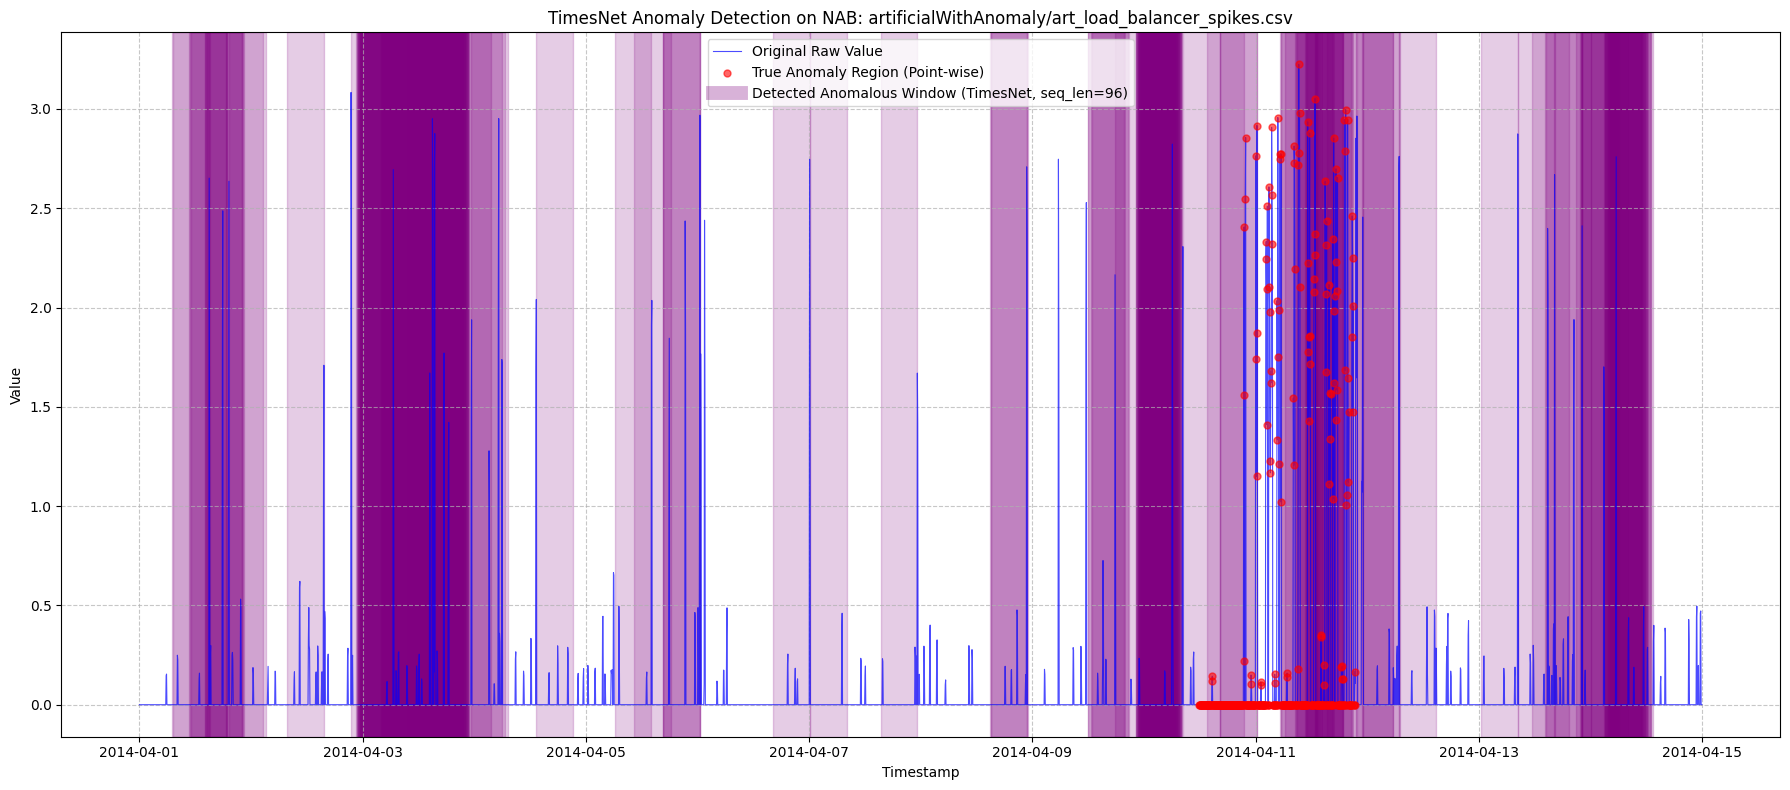

--- Visualization (TimesNet) Complete ---

--- End of Script ---


In [15]:
# @title 8. 最终可视化 (原始数据上的异常窗口)
# ------------------------------------------------------------------------------
# 在原始时间序列数据上展示真实的异常区域和TimesNet检测到的异常窗口。
# ------------------------------------------------------------------------------
print(f"\n--- Final Visualization (TimesNet on Raw Data with Detected Windows) ---")

# 确保所有必要的数据都已准备好 (与temp.py的检查类似，但针对TimesNet的变量)
if (data_df is not None and not data_df.empty and # 原始数据 DataFrame
    WINDOW_SIZE is not None and                 # 窗口大小
    'predicted_window_anomalies_bool_tsn' in locals() and # TimesNet的窗口预测结果
    predicted_window_anomalies_bool_tsn is not None and
    X_windowed_data_np is not None and X_windowed_data_np.shape[0] > 0 and # 用于确定窗口数量和时间戳对齐
    len(predicted_window_anomalies_bool_tsn) == X_windowed_data_np.shape[0]): # 确保预测结果与窗口数量一致

    plt.figure(figsize=(18, 8))

    # 绘制原始数据值 (与temp.py一致)
    plt.plot(data_df.index, data_df['value'], label='Original Raw Value', color='blue', linewidth=0.8, alpha=0.7)

    # 标记真实的异常区域 (逐点) (与temp.py一致)
    true_anomalies_plot_df = data_df[data_df['is_anomaly_pointwise'] == 1]
    if not true_anomalies_plot_df.empty:
        plt.scatter(true_anomalies_plot_df.index,
                    true_anomalies_plot_df['value'],
                    color='red', label='True Anomaly Region (Point-wise)', marker='o', s=25, alpha=0.6, zorder=3)

    # 标记TimesNet检测到的异常窗口 (与temp.py一致，但使用TimesNet的预测)
    num_windows_for_vis = X_windowed_data_np.shape[0] # 窗口数量
    detected_windows_marked_tsn = False

    for i in range(num_windows_for_vis):
        if predicted_window_anomalies_bool_tsn[i]: # 如果这个窗口被预测为异常
            # 获取窗口的开始和结束时间戳
            # 窗口 i 对应于 data_df.index[i] 到 data_df.index[i + WINDOW_SIZE - 1]
            if i + WINDOW_SIZE <= len(data_df.index): # 确保窗口不越界
                window_start_time = data_df.index[i]
                window_end_time = data_df.index[i + WINDOW_SIZE - 1] # 窗口的最后一个点

                # 使用 axvspan 标记整个窗口区域
                plt.axvspan(window_start_time, window_end_time, color='purple', alpha=0.2, label='_nolegend_')
                detected_windows_marked_tsn = True

    # 添加一个图例项给检测到的窗口 (如果至少标记了一个)
    if detected_windows_marked_tsn:
        plt.plot([], [], color='purple', alpha=0.3, linewidth=10, label=f'Detected Anomalous Window (TimesNet, seq_len={WINDOW_SIZE})')

    plt.title(f"TimesNet Anomaly Detection on NAB: {NAB_DATA_FILE_RELATIVE_PATH}")
    plt.xlabel("Timestamp")
    plt.ylabel("Value")
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

else:
    print("Skipping final visualization for TimesNet as some prerequisites are not met or data is inconsistent.")
    print("  Debugging info for visualization skip:")
    print(f"    data_df is None or empty: {data_df is None or data_df.empty}")
    print(f"    WINDOW_SIZE is None: {WINDOW_SIZE is None}")
    if 'predicted_window_anomalies_bool_tsn' in locals():
        print(f"    predicted_window_anomalies_bool_tsn is None: {predicted_window_anomalies_bool_tsn is None}")
        if predicted_window_anomalies_bool_tsn is not None and X_windowed_data_np is not None:
             print(f"    len(predicted_window_anomalies_bool_tsn) [{len(predicted_window_anomalies_bool_tsn)}] == X_windowed_data_np.shape[0] [{X_windowed_data_np.shape[0]}]: {len(predicted_window_anomalies_bool_tsn) == X_windowed_data_np.shape[0] if X_windowed_data_np is not None else 'X_windowed_data_np is None'}")
    else:
        print(f"    'predicted_window_anomalies_bool_tsn' not in locals")
    print(f"    X_windowed_data_np is None or empty: {X_windowed_data_np is None or X_windowed_data_np.shape[0] == 0}")


print(f"--- Visualization (TimesNet) Complete ---")
print("\n--- End of Script ---")